In [19]:
#Import Library yang dibutuhkan
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

https://drive.google.com/file/d/1tuAXrkjb0s4ncFzHJm7O10vvYxwQdHVC/view?usp=drive_link

In [20]:
# Import gdown dan unduh file dari Google Drive menggunakan File ID
import gdown
file_id = "1tuAXrkjb0s4ncFzHJm7O10vvYxwQdHVC"
url = f"https://drive.google.com/uc?id={file_id}"
gdown.download(url, "data.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1tuAXrkjb0s4ncFzHJm7O10vvYxwQdHVC
To: /content/data.csv
100%|██████████| 125k/125k [00:00<00:00, 39.2MB/s]


'data.csv'

In [21]:
# Membaca file CSV yang sudah diunduh ke DataFrame dan menampilkan 5 baris pertamanya
df = pd.read_csv("data.csv")
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [22]:
# Menampilkan ringkasan data, termasuk tipe data dan status nilai hilang
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [23]:
# Membuat salinan DataFrame baru dan menghapus kolom 'id' karena tidak relevan untuk klasifikasi
dataset = df.drop(["id"], axis = 1)

In [24]:
# Menghapus kolom 'Unnamed: 32' karena kolom ini berisi nilai yang hilang (NaN) atau kosong
dataset = df.drop(["Unnamed: 32"], axis = 1)

In [25]:
# Menampilkan 3 baris pertama dari DataFrame 'dataset' yang sudah dibersihkan (untuk inspeksi)
dataset.head(3)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [26]:
# Membuat subset (DataFrame baru) yang hanya berisi data dengan diagnosis Malignant ("M" / Ganas)
M = dataset[dataset.diagnosis == "M"]

In [27]:
# Menampilkan 5 baris pertama dari DataFrame M (hanya diagnosis Malignant/Ganas)
M.head(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [28]:
# Filter data untuk diagnosis "B" (Benign)
B = dataset[dataset.diagnosis == "B"]

In [29]:
# Menampilkan 5 baris pertama dari data Benign (B)
B.head(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
19,8510426,B,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,...,15.110,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259
20,8510653,B,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,...,14.500,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183
21,8510824,B,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,...,10.230,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773
37,854941,B,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,...,13.300,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169
46,85713702,B,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,...,8.964,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409


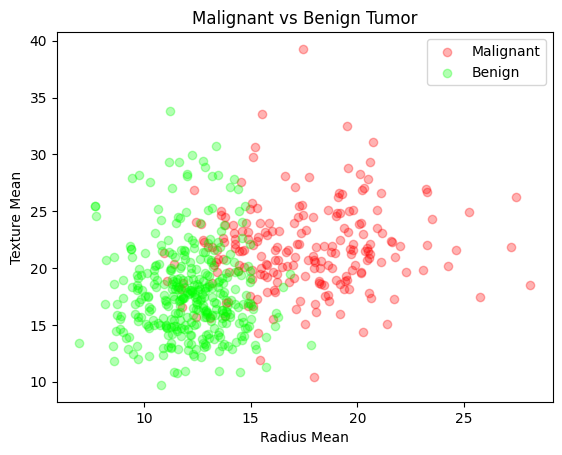

In [30]:
# Membuat diagram pencar (scatter plot) yang membandingkan Malignant (M) dan Benign (B) berdasarkan Radius Mean dan Texture Mean.
plt.title("Malignant vs Benign Tumor")
plt.xlabel("Radius Mean")
plt.ylabel("Texture Mean")
plt.scatter(M.radius_mean, M.texture_mean, color = "red", label = "Malignant", alpha = 0.3)
plt.scatter(B.radius_mean, B.texture_mean, color = "lime", label = "Benign", alpha = 0.3)
plt.legend()
plt.show()

In [31]:
# Mengubah nilai kolom 'diagnosis' dari kategori teks ('M', 'B') menjadi numerik (1, 0).
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [32]:
# Mengubah diagnosis teks ("M", "B") menjadi numerik (1, 0) menggunakan list comprehension.
dataset.diagnosis = [1 if i == "M" else 0 for i in dataset.diagnosis]

In [33]:
# Periksa nilai yang hilang dan mengisi jika ada
print("\nJumlah nilai hilang per kolom:")
print(df.isnull().sum().sort_values(ascending=False).head())


Jumlah nilai hilang per kolom:
Unnamed: 32     569
id                0
diagnosis         0
texture_mean      0
radius_mean       0
dtype: int64


In [34]:
# Memisahkan fitur (x) dengan menghilangkan kolom 'diagnosis', dan variabel target (y).
x = dataset.drop(["diagnosis"], axis = 1)
y = dataset.diagnosis.values

In [35]:
# Normalisasi (Min-Max Scaling) fitur data (x) ke rentang [0, 1].
x = (x - np.min(x)) / (np.max(x) - np.min(x))

In [36]:
# Standardisasi fitur data (x) menggunakan StandardScaler.
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x = pd.DataFrame(x_scaled, columns=x.columns)

In [37]:
# Membagi data dengan rasio 80% Latih (Train) dan 20% Uji (Test)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
# Menampilkan bentuk (jumlah baris dan kolom) dari data fitur pelatihan dan pengujian.
print(f"\nBentuk X_train: {X_train.shape}")
print(f"Bentuk X_test: {X_test.shape}")


Bentuk X_train: (455, 31)
Bentuk X_test: (114, 31)


In [39]:
# Menginisiasi dan melatih model klasifikasi Gaussian Naive Bayes.
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)

GaussianNB()

In [40]:
# Menggunakan Gaussian Naive Bayes
model_nb = GaussianNB()

In [41]:
# Melatih model dengan data latih
print("\nMemulai pelatihan model Gaussian Naive Bayes...")
model_nb.fit(X_train, y_train)
print("Pelatihan selesai.")


Memulai pelatihan model Gaussian Naive Bayes...
Pelatihan selesai.


In [42]:
# Membuat prediksi pada data uji (X_test)
y_pred = model_nb.predict(X_test)

In [43]:
# Membuat prediksi probabilitas (untuk analisis lebih lanjut, jika diperlukan)
y_proba = model_nb.predict_proba(X_test)

In [44]:
# Akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"\n--- HASIL EVALUASI MODEL NAIVE BAYES ---")
print(f"Akurasi Model: {accuracy:.4f}")


--- HASIL EVALUASI MODEL NAIVE BAYES ---
Akurasi Model: 0.9211


In [45]:
# Menampilkan akurasi (score) model Naive Bayes menggunakan data pengujian.
print("Naive Bayes score: ",nb.score(X_test, y_test))

Naive Bayes score:  0.9210526315789473


In [46]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nMatriks Kebingungan (Confusion Matrix):")
print(cm)
print("""
[ True Negative  | False Positive ]
[ False Negative | True Positive  ]
""")


Matriks Kebingungan (Confusion Matrix):
[[69  3]
 [ 6 36]]

[ True Negative  | False Positive ]
[ False Negative | True Positive  ]



In [47]:
# Classification Report
# Menunjukkan Precision, Recall, dan F1-Score untuk setiap kelas (0: Benign, 1: Malignant)
print("\nLaporan Klasifikasi (Classification Report):")
print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Malignant (1)']))


Laporan Klasifikasi (Classification Report):
               precision    recall  f1-score   support

   Benign (0)       0.92      0.96      0.94        72
Malignant (1)       0.92      0.86      0.89        42

     accuracy                           0.92       114
    macro avg       0.92      0.91      0.91       114
 weighted avg       0.92      0.92      0.92       114



In [48]:
#INTERPRETASI SINGKAT
tn, fp, fn, tp = cm.ravel()
print(f"-> Model memprediksi {tp} kasus Malignant (Ganas) dengan benar (True Positive).")
print(f"-> Model memprediksi {fn} kasus Malignant (Ganas) sebagai Benign (Jinak) (False Negative).")

-> Model memprediksi 36 kasus Malignant (Ganas) dengan benar (True Positive).
-> Model memprediksi 6 kasus Malignant (Ganas) sebagai Benign (Jinak) (False Negative).
